# Data Quality and Similarity Evalution

This notebook contains the ... for measuring Data Quality (LO) and ....

## Setup

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [14]:
import sys, os, warnings, datetime
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from lib import transformations, datasets

In [15]:
# Keeping pandas from truncating long strings
pd.set_option('display.max_colwidth',   120)

In [16]:
# Folders constants
data_dir_path = 'data'

dataset_dir_path = f'{data_dir_path}/dataset'
images_dir_path   = f'{data_dir_path}/images'

## Dataset

Load the dataframe with data acquired during the collects.

In [17]:
dataset_v0 = pd.read_csv(f'{dataset_dir_path}/suited_dataset.csv')
dataset_v0.shape

(1772, 8)

In [18]:
ds_loader = datasets.Dataset()
images_by_depth = {}

In [19]:
'''
Load and transform an image of name [img_file_name] from data folder. 
The transformations applied are:
- NoiseRemovalSetMaxValue: ...
- AdjustScaleWithFixedMaxValue
'''
def get_img_file(img_file_name: str):
    if img_file_name in images_by_depth:
        return images_by_depth[img_file_name]
    else: 
        img_file = ds_loader.load_img(
            img_file_name=img_file_name, 
            img_dir=images_dir_path,
            transformations = [
                transformations.NoiseRemovalSetMaxValue(max_value=1950),
                transformations.AdjustScaleWithFixedMaxValue(max_value=1950),
            ]
        )
        images_by_depth[img_file_name] = img_file
        return img_file

## 2. Quality Analysis

In this section, the **QI** index is measured for each image of the suited dataset images.

### 2.1 Measure the Laplacian-based Quality Index (QI)

In [20]:
from skimage.filters import laplace

vlr_by_img = []
ksize = 3
'''
lore ipsum ...
'''
def measuse_laplace(row: pd.Series):
    img_file_name = row['depth']
    img_file = get_img_file(img_file_name)

    vlr_by_img.append({
        'depth':img_file_name, 
        'qi':np.abs(laplace(img_file, ksize=ksize)).sum()
    })

dataset_v0.apply(measuse_laplace, axis=1)
len(vlr_by_img)

1772

In [21]:
ds_qi_by_img_v0 = pd.DataFrame.from_dict(vlr_by_img)
ds_qi_by_img_v0.head()

,depth,qi
0,0200_15565_2025_01_26_09_07_57_912318_DEPTH_320_240_1.png,5943.262695
1,0200_15566_2025_01_26_09_07_58_014755_DEPTH_320_240_1.png,5965.407715
2,0200_15567_2025_01_26_09_07_58_123809_DEPTH_320_240_1.png,5920.653320
3,0200_15569_2025_01_26_09_07_58_344763_DEPTH_320_240_1.png,5831.576172
4,0200_15568_2025_01_26_09_07_58_235040_DEPTH_320_240_1.png,5729.493164


Export the **QI** index to be used in other analysis

In [22]:
import csv

# The keys of the dictionaries become the CSV headers
fieldnames = vlr_by_img[0].keys()

with open(f'output/qi_per_img_{ksize}.csv', 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()         # Writes the header row
    writer.writerows(vlr_by_img) # Writes all the data rows

### 2.2 Statistical Analysis

....

In [23]:
farm_A_query = 'farm == "Farm A"'
farm_B_query = 'farm == "Farm B"'

'''
Measure the confidence interval ...
'''
def get_ci(data, conf=0.95):
    if len(data) <= 1: return [np.nan, np.nan]
    ci = stats.t.interval(
        conf, 
        len(data)-1, 
        loc=data.mean(), 
        scale=stats.sem(data)
    )
    
    return f"{ci[0]:.3f} - {ci[1]:.3f}"

In [24]:
dataset_v1 = dataset_v0.merge(ds_qi_by_img_v0, on='depth')
dataset_v1.shape

(1772, 9)

#### General

Calculates ...

In [66]:
ds_qi_stats = dataset_v1[['qi']].describe()

ds_qi_stats.loc['cv','qi'] = ds_qi_stats.loc['std','qi'] / ds_qi_stats.loc['mean','qi'] * 100
ds_qi_stats.loc['ci','qi'] = get_ci(dataset_v1['qi'])

ds_qi_stats

,qi
count,1772.0
mean,4251.753418
std,1425.475708
min,3034.006104
25%,3299.985413
50%,3410.723633
75%,5858.075439
max,9160.046875
cv,33.526773
ci,4185.337 - 4318.169


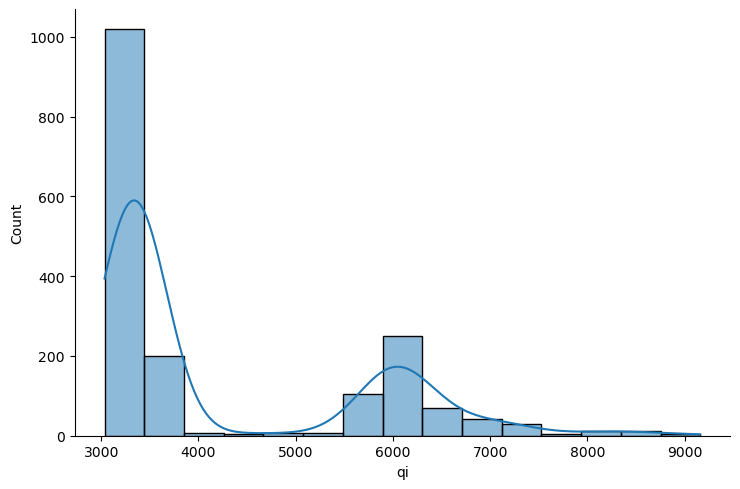

In [53]:
qi_distplot = sns.displot(
    dataset_v1, 
    x="qi",
    aspect=1.5,
    kde=True,
)

# qi_distplot.savefig(
#     f'{figures_dir_path}/qi_distplot.png', 
#     dpi=600, , 
#     bbox_inches="tight"
# )

#### By Farm

In [68]:
ds_qi_by_farm_stats = dataset_v1.groupby(['farm']).agg({
    'qi':['min', 'mean', 'median', 'max', 'std', 'var', get_ci]
}).reset_index()

ds_qi_by_farm_stats.columns = ['farm', 'min', 'mean', 'median', 'max', 'std', 'var', 'ci']
ds_qi_by_farm_stats['cv'] = ds_qi_by_farm_stats.apply(
    lambda row: row['std'] / row['mean'] * 100, axis=1
)

ds_qi_by_farm_stats.head()

,farm,min,mean,median,max,std,var,ci,cv
0,Farm A,3912.480225,6266.593750,6095.894531,9160.046875,752.718881,566586.750000,6203.777 - 6329.411,12.011611
1,Farm B,3034.006104,3335.315186,3346.054932,3565.091309,104.769358,10976.631836,3329.426 - 3341.205,3.141213


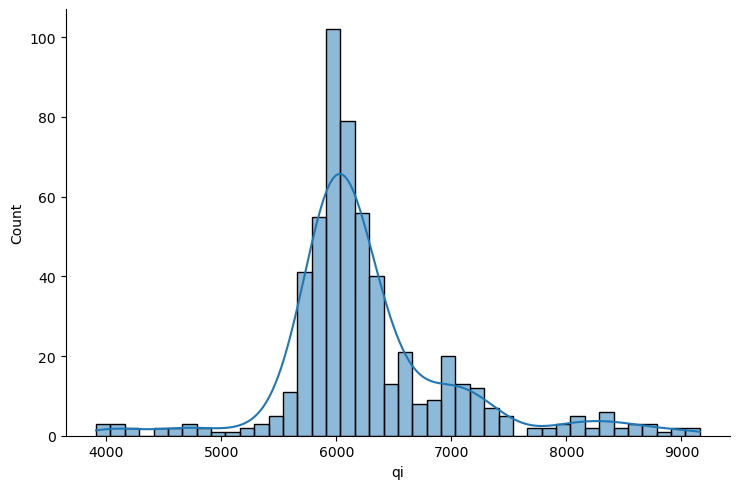

In [73]:
qi_distplot_farmA = sns.displot(
    dataset_v1.query(farm_A_query), 
    x="qi",
    aspect=1.5,
    kde=True,
)
# qi_distplot_farmA.ax.set_xlim(75, 280)

# qi_distplot_farmA.savefig(
#     f'{figures_dir_path}/dataset-charts/q_distplot.png', 
#     dpi=600
# )

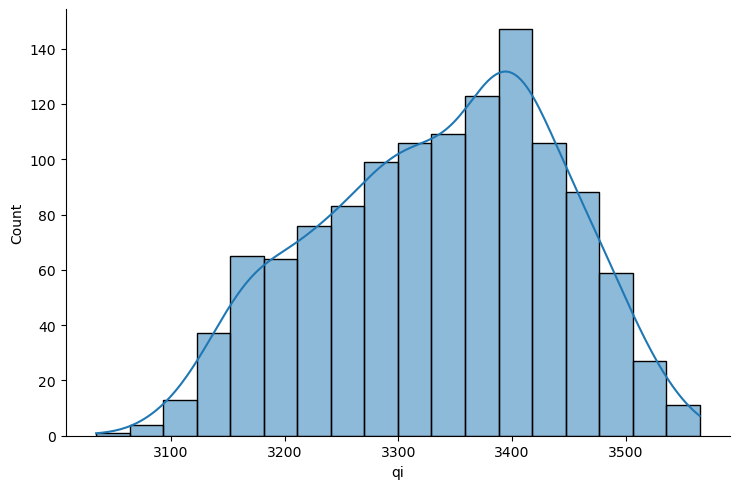

In [74]:
qi_distplot_farmB = sns.displot(
    dataset_v1.query(farm_B_query), 
    x="qi",
    aspect=1.5,
    kde=True,
)
# qi_distplot_farmA.ax.set_xlim(75, 280)

# qi_distplot_farmA.savefig(
#     f'{figures_dir_path}/dataset-charts/q_distplot.png', 
#     dpi=600
# )

### 2.3 Correlation Analysis - QI x Weight

#### General

In [75]:
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1['weight'], 
    dataset_v1['qi']
)

print({
    'coeff':correlation_coefficient, 
    'p-value': p_value
})

{'coeff': 0.1478503411503834, 'p-value': 4.0061933368319313e-10}


#### By Farm

In [77]:
corr_dict = {}

# Farm A
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_A_query)['weight'], 
    dataset_v1.query(farm_A_query)['qi']
)

corr_dict['Farm A'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

# Farm B
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_B_query)['weight'], 
    dataset_v1.query(farm_B_query)['qi']
)
corr_dict['Farm B'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

pd.DataFrame.from_dict(corr_dict)

,Farm A,Farm B
coeff,-0.24530954,-0.00083218
p-value,0.0,0.976854


### 2.4 Correlation - QI x Capture Time

#### General

In [25]:
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1['captured_at_as_min'], 
    dataset_v1['qi']
)
print({
    'coeff':correlation_coefficient, 
    'p-value': p_value
})

{'coeff': -0.92769172173509, 'p-value': 0.0}


#### By Farm

In [85]:
corr_dict = {}

# Farm A
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_A_query)['captured_at_as_min'], 
    dataset_v1.query(farm_A_query)['qi']
)

corr_dict['Farm A'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

# Farm B
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_B_query)['captured_at_as_min'], 
    dataset_v1.query(farm_B_query)['qi']
)
corr_dict['Farm B'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

pd.DataFrame.from_dict(corr_dict)

,Farm A,Farm B
coeff,0.41611967,-0.37224721
p-value,0.0,0.0


### 2.5 Intra-animal Variability Index

In [26]:
ds_qi_by_animal_stats = dataset_v1.groupby([
    'farm','animal_id'
]).agg({
    'qi':['min', 'mean', 'median', 'max', 'std', 'var'],
    'captured_at_as_min':['min'],
}).reset_index()

ds_qi_by_animal_stats.columns = [
    'farm', 'animal_id', 'min', 'mean', 'median', 'max', 'std', 'var', 'time'
]
ds_qi_by_animal_stats['cv'] = ds_qi_by_animal_stats.apply(
    lambda row: row['std'] / row['mean'] * 100, axis=1
)

ds_qi_by_animal_stats.head()

,farm,animal_id,min,mean,median,max,std,var,time,cv
0,Farm A,021IK4BJ2GltxzphIRtY,5729.493164,5887.851562,5920.653320,6057.125977,116.588883,13592.971680,547,1.980160
1,Farm A,0H0P02DmDniAyI9krMhA,6111.584961,6218.892578,6195.159180,6342.929688,70.424317,4959.570312,658,1.132425
2,Farm A,0ZwJ8fjJa9TowXrYWhEE,6518.288086,6554.899902,6568.848145,6577.563477,32.004813,1024.308105,668,0.488258
3,Farm A,1blNoXOaGTVs8uJGMp52,5676.834961,5749.948242,5744.840332,5833.277344,66.419535,4411.544922,648,1.155133
4,Farm A,2ttYmLWSz3gTJr7nWhqH,5662.193848,6345.507324,6504.971191,6589.772461,339.898945,115531.171875,645,5.356529


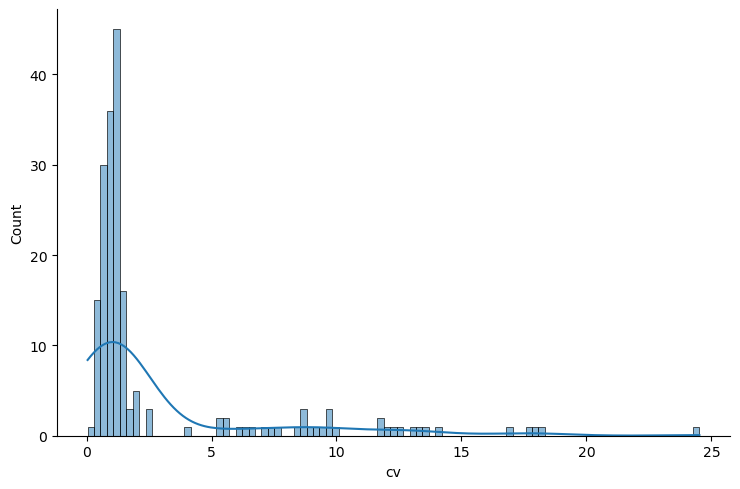

In [97]:
ds_qi_by_animal_distplot = sns.displot(
    ds_qi_by_animal_stats, 
    x="cv",
    aspect=1.5,
    kde=True,
)

#### General

In [109]:
ds_qi_vi_stats = ds_qi_by_animal_stats[['cv']].describe()

ds_qi_vi_stats.loc['vi','cv'] = ds_qi_vi_stats.loc['std','cv'] / ds_qi_vi_stats.loc['mean','cv'] * 100
ds_qi_vi_stats.loc['ci','cv'] = get_ci(ds_qi_vi_stats['cv'])

ds_qi_vi_stats

,cv
count,190.0
mean,2.84325
std,4.205674
min,0.043521
25%,0.822663
50%,1.128781
75%,1.566663
max,24.520873
vi,147.917842
ci,-15.002 - 97.901


In [28]:
correlation_coefficient, p_value = stats.pearsonr(
    ds_qi_by_animal_stats['time'], 
    ds_qi_by_animal_stats['cv']
)
print({
    'coeff':correlation_coefficient, 
    'p-value': p_value
})

{'coeff': -0.41550063086281064, 'p-value': 2.503891542566073e-09}


#### By Farm

In [103]:
ds_qi_vi_by_farm_stats = ds_qi_by_animal_stats.groupby('farm').agg({
    'cv':['min', 'mean', 'median', 'max', 'std', 'var', get_ci]
}).reset_index()

ds_qi_vi_by_farm_stats.columns = ['farm', 'min', 'mean', 'median', 'max', 'std', 'var', 'ci']
ds_qi_vi_by_farm_stats['vi'] = ds_qi_vi_by_farm_stats.apply(
    lambda row: row['std'] / row['mean'] * 100, axis=1
)

ds_qi_vi_by_farm_stats.head()

,farm,min,mean,median,max,std,var,ci,vi
0,Farm A,0.378025,4.826902,1.497414,24.520873,5.415513,29.327783,3.699 - 5.955,112.194399
1,Farm B,0.043521,1.019893,1.017639,2.573806,0.407355,0.165938,0.939 - 1.101,39.940896


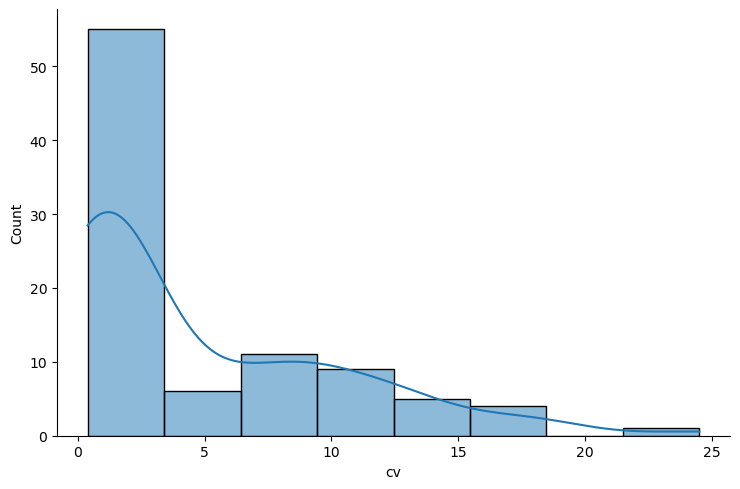

In [101]:
qi_vi_distplot_farmA = sns.displot(
    ds_qi_by_animal_stats.query(farm_A_query), 
    x="cv",
    aspect=1.5,
    kde=True,
)

# qi_vi_distplot_farmA.ax.set_xlim(0, 25)

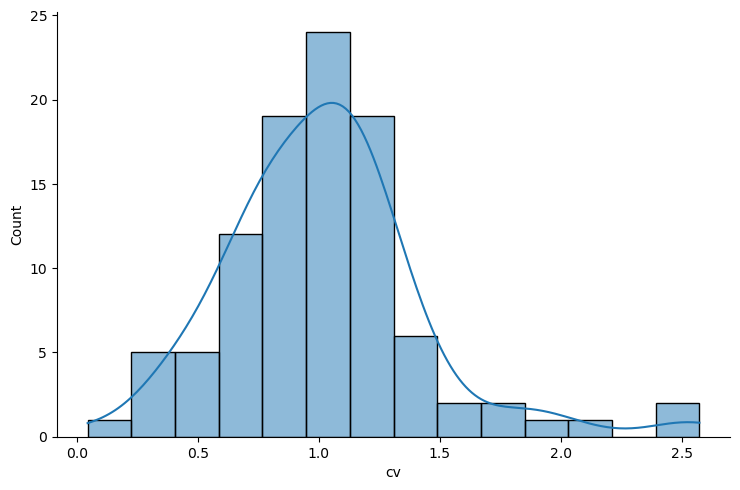

In [102]:
qi_vi_distplot_farmB = sns.displot(
    ds_qi_by_animal_stats.query(farm_B_query), 
    x="cv",
    aspect=1.5,
    kde=True,
)

# qi_vi_distplot_farmA.ax.set_xlim(0, 25)

### 2.6 GMML ....

carried out in R by the file ....

## 3. Image Similarity Analysis

In this section, the similarity metrics RMSE, SSIM and pHash are measured comparing images in differente scenarios: **overall**, **intra-animal**, **intra-farm** and **inter-farm**.

### Functions

In [428]:
import imagehash

from skimage.metrics import structural_similarity as ssim
from PIL import Image
from scipy.stats import wasserstein_distance

'''
Function that measure the similarity between two images.
'''
def measure_similarity(img1: np.array, img2: np.array) -> dict:
    h1 = imagehash.phash(Image.fromarray(img1))
    h2 = imagehash.phash(Image.fromarray(img2))
    
    hist1, _ = np.histogram(img1)
    hist2, _ = np.histogram(img2)
    
    hist1 = hist1.flatten()/hist1.sum()
    hist2 = hist2.flatten()/hist2.sum()
    
    emd = wasserstein_distance(hist2, hist1)
    
    return {
        'ssim':ssim(img2, img1, data_range=1.0),
        'mse':np.mean((img2 - img1) ** 2),
        'rmse':np.mean(np.sqrt((img2 - img1) ** 2)),
        'phash':h2 - h1,
        'emd': emd,
    }

In [429]:
# Queries used to filter data by Farm from the dataset
farm_A_query = 'place == "Divino - Curral 1"'
farm_B_query = 'place == "Jarbson"'

In [430]:
'''
Measure the confidence interval ...
'''
def get_ci(data, conf=0.95):
    if len(data) <= 1: return [np.nan, np.nan]
    ci = stats.t.interval(
        conf, 
        len(data)-1, 
        loc=data.mean(), 
        scale=stats.sem(data)
    )
    return (f"{ci[0]:.3f}", f"{ci[1]:.3f}")

'''
Calculate the similarity metrics agregation ... 
- data_dict: is a dict in the format:
  {
    'src_type': value,
    'thing_id': value,
    'farm':value,
    'img1_name': value,
    'img2_name': value, 
    'ssim': value, 
    'mse': value,
    'rmse': value, 
    'mpe': value,
    'phash': value,
  }
'''
def calculate_metrics(data_dict: dict, by_farm_too: bool = True) -> pd.DataFrame:
    ds_dict_v0 = pd.DataFrame.from_dict(data_dict)
    
    # variables
    _cols = ['src_type','ssim_mean','ssim_std','ssim_get_ci','mse_mean','mse_std','mse_get_ci','rmse_mean','rmse_std','rmse_get_ci','phash_mean','phash_std','phash_get_ci','emd_mean','emd_std','emd_get_ci']
    _stats = ['mean','std', get_ci]

    # overall
    ds_stats_v0 = ds_dict_v0.groupby('src_type').agg({
        'ssim':_stats,
        'mse':_stats,
        'rmse':_stats,
        'phash':_stats,
        'emd':_stats,
    }).reset_index()
    
    ds_stats_v0.columns = _cols
    ds_stats_v0['src_type'] = 'overall'

    if not by_farm_too:
        return ds_stats_v0

    # By Farm
    ds_by_farm_stats_v0 = ds_dict_v0.groupby(['farm']).agg({
        'ssim':_stats,
        'mse':_stats,
        'rmse':_stats,
        'phash':_stats,
        'emd':_stats,
    }).reset_index()
    
    ds_by_farm_stats_v0.columns = _cols

    # Final version
    return pd.concat(
        [ds_stats_v0, ds_by_farm_stats_v0], 
        ignore_index=True
    )

### 3.1 Image Similarity Metrics to Whole Data

In this case, the images are compared with other randomly ...

In [329]:
import random

src_overall_dict = []
last_img = None

def overall_sim(row1: pd.Series, row2: pd.Series):
    sim_metrics = measure_similarity(
        img1=get_img_file(row1['depth']), 
        img2=get_img_file(row2['depth'])
    )

    src_overall_dict.append({
        'src_type': 'intra-farm',
        'thing_id':row1['thing_id'],
        'farm': row1['place'],
        'img1_name': row1['depth'], 
        'img2_name': row2['depth'],
        'ssim':sim_metrics['ssim'],
        'mse':sim_metrics['mse'],
        'rmse':sim_metrics['rmse'],
        'phash':sim_metrics['phash'],
        'emd':sim_metrics['emd'],
    })

animals = list(dataset_v1['thing_id'].unique())
for i in range(0, dataset_v1.shape[0] * 5):
    # Select two unique random values from [animal_set]
    random_values = random.sample(animals, 2)
    
    row1 = dataset_v1.query(f'thing_id == "{random_values[0]}"').sample().iloc[0]
    row2 = dataset_v1.query(f'thing_id == "{random_values[1]}"').sample().iloc[0]
    
    overall_sim(row1=row1, row2=row2)

ds_src_overall_dict_v0 = pd.DataFrame.from_dict(src_overall_dict)
ds_src_overall_dict_v0.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,intra-farm,egbveuFX7hSAg8Cgwuya,Divino - Curral 1,0062_5176_2025_01_25_11_08_03_541779_DEPTH_320_240_1.png,0071vd_6989_2025_01_25_16_52_25_160971_DEPTH_320_240_1.png,0.219920,0.066773,0.207580,32,0.067469
1,intra-farm,NAmvD9ytvupDGxiV3C4a,Divino - Curral 1,0128_2742_2025_01_25_10_50_03_868761_DEPTH_320_240_1.png,0024vd_8771_2025_01_25_16_58_17_816181_DEPTH_320_240_1.png,0.227025,0.032428,0.155172,0,0.057417
2,intra-farm,ji3O1Lv5gg38uStwh8eI,Jarbson,5mf_14451_2025_01_25_17_45_44_743864_DEPTH_320_240_1.png,0024br_12371_2025_01_25_17_18_53_438547_DEPTH_320_240_1.png,0.666195,0.004773,0.044140,32,0.008690
3,intra-farm,IKcaWgp5Sjx6h5JeMPM4,Jarbson,0127vd_12316_2025_01_25_17_18_35_557354_DEPTH_320_240_1.png,0131az_12258_2025_01_25_17_18_15_735187_DEPTH_320_240_1.png,0.615528,0.003691,0.040602,32,0.004138
4,intra-farm,SfCAdVVBlzveBsOAmKtf,Divino - Curral 1,975_2053_2025_01_25_10_46_32_720234_DEPTH_320_240_1.png,4mf_14390_2025_01_25_17_45_05_204438_DEPTH_320_240_1.png,0.252205,0.036635,0.165978,32,0.047076


### 3.1 Intra-animal Image Similarity Metrics

.... between sequential images of an animal

In [331]:
src_intra_animal_dict = []
last_img = None

def intra_animal_sim(row: pd.Series):
    global last_img
    
    img_file_name = row['depth']
    thing_id = row['thing_id']
    img_file = get_img_file(img_file_name)
    
    if last_img is not None and last_img['thing_id'] == thing_id:
        sim_metrics = measure_similarity(
            img1=last_img['data'], 
            img2=img_file
        )

        src_intra_animal_dict.append({
            'src_type': 'intra-animal',
            'thing_id':thing_id,
            'farm': row['place'],
            'img1_name': last_img['file_name'], 
            'img2_name': img_file_name,
            'ssim':sim_metrics['ssim'],
            'mse':sim_metrics['mse'],
            'rmse':sim_metrics['rmse'],
            'phash':sim_metrics['phash'],
            'emd':sim_metrics['emd'],
        })
    
    last_img = {
        'file_name':img_file_name,
        'data': img_file,
        'thing_id': thing_id
    }

dataset_v1.sort_values(
    by=['happenedAt','thing_id','begin_at']
).iloc[:,:].apply(intra_animal_sim, axis=1)

ds_src_intra_animal_dict_v0 = pd.DataFrame.from_dict(src_intra_animal_dict)
ds_src_intra_animal_dict_v0.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,intra-animal,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3668_2025_01_25_10_58_56_590053_DEPTH_320_240_1.png,1001_3669_2025_01_25_10_58_56_692475_DEPTH_320_240_1.png,0.235862,13321.579414,93.584557,40,0.003198
1,intra-animal,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3669_2025_01_25_10_58_56_692475_DEPTH_320_240_1.png,1001_3670_2025_01_25_10_58_56_798206_DEPTH_320_240_1.png,0.256289,12859.750430,91.642868,28,0.002417
2,intra-animal,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3670_2025_01_25_10_58_56_798206_DEPTH_320_240_1.png,1001_3671_2025_01_25_10_58_56_901236_DEPTH_320_240_1.png,0.260638,12889.590260,91.967758,30,0.003529
3,intra-animal,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3671_2025_01_25_10_58_56_901236_DEPTH_320_240_1.png,1001_3672_2025_01_25_10_58_57_012022_DEPTH_320_240_1.png,0.254410,12994.587357,92.121780,44,0.008417
4,intra-animal,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3672_2025_01_25_10_58_57_012022_DEPTH_320_240_1.png,1001_3673_2025_01_25_10_58_57_110697_DEPTH_320_240_1.png,0.257603,12905.832344,91.795181,30,0.002255


### 3.2 Intra-farm Image Similarity Metrics

In this case, the images are compared with images of the same farm but from different animal

In [463]:
ds_farm_B.shape[0] * 5

6090

In [333]:
import random

src_intra_farm_dict = []
last_img = None

def intra_farm_sim(row1: pd.Series, row2: pd.Series):
    sim_metrics = measure_similarity(
        img1=get_img_file(row1['depth']), 
        img2=get_img_file(row2['depth'])
    )

    src_intra_farm_dict.append({
        'src_type': 'intra-farm',
        'thing_id':row1['thing_id'],
        'farm': row1['place'],
        'img1_name': row1['depth'], 
        'img2_name': row2['depth'],
        'ssim':sim_metrics['ssim'],
        'mse':sim_metrics['mse'],
        'rmse':sim_metrics['rmse'],
        'phash':sim_metrics['phash'],
        'emd':sim_metrics['emd'],
    })

# Farm A
ds_farm_A = dataset_v1.query(farm_A_query).iloc[:,:]

animals = list(ds_farm_A['thing_id'].unique())
for i in range(0, ds_farm_A.shape[0] * 5):
    # Select two unique random values from [animal_set]
    random_values = random.sample(animals, 2)
    
    row1 = ds_farm_A.query(f'thing_id == "{random_values[0]}"').sample().iloc[0]
    row2 = ds_farm_A.query(f'thing_id == "{random_values[1]}"').sample().iloc[0]
    
    intra_farm_sim(row1=row1, row2=row2)

# Farm B
ds_farm_B = dataset_v1.query(farm_B_query).iloc[:,:]

animals = list(ds_farm_B['thing_id'].unique())
for i in range(0, ds_farm_B.shape[0] * 5):
    # Select two unique random values from [animal_set]
    random_values = random.sample(animals, 2)
    
    row1 = ds_farm_B.query(f'thing_id == "{random_values[0]}"').sample().iloc[0]
    row2 = ds_farm_B.query(f'thing_id == "{random_values[1]}"').sample().iloc[0]
    
    intra_farm_sim(row1=row1, row2=row2)

ds_src_intra_farm_dict_v0 = pd.DataFrame.from_dict(src_intra_farm_dict)
ds_src_intra_farm_dict_v0.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,intra-farm,Z4fUNm6iiq9A2rlLKU7i,Divino - Curral 1,0047_3511_2025_01_25_10_54_54_983106_DEPTH_320_240_1.png,0015_5385_2025_01_25_11_08_59_878590_DEPTH_320_240_1.png,0.400071,0.015797,0.090306,32,0.028799
1,intra-farm,OXkEYT36NMADvZaMMGn8,Divino - Curral 1,0262_15136_2025_01_26_09_04_32_106834_DEPTH_320_240_1.png,0020_2654_2025_01_25_10_49_47_156998_DEPTH_320_240_1.png,0.302623,0.026716,0.125790,0,0.020917
2,intra-farm,zbbrTxhhcZBu0NL7dnuZ,Divino - Curral 1,59_3769_2025_01_25_10_59_17_013332_DEPTH_320_240_1.png,909_16205_2025_01_26_09_10_59_176928_DEPTH_320_240_1.png,0.304308,0.025974,0.130505,0,0.011029
3,intra-farm,wxQWar4b3KtXqJAzSPys,Divino - Curral 1,0277_314_2025_01_25_10_30_03_269796_DEPTH_320_240_1.png,1003_1519_2025_01_25_10_43_52_053628_DEPTH_320_240_1.png,0.338818,0.013763,0.083762,0,0.015630
4,intra-farm,POwChBmKnJiUjAdX3PFB,Divino - Curral 1,982_2542_2025_01_25_10_49_16_472602_DEPTH_320_240_1.png,998_4277_2025_01_25_11_02_01_922497_DEPTH_320_240_1.png,0.334572,0.011299,0.073727,0,0.005237


### 3.3 Inter-farm Image Similarity Metrics

In this case, the images are compared with images of other farm animal

In [432]:
import random

src_between_farm_dict = []
last_img = None

def between_farm_sim(row1: pd.Series, row2: pd.Series):
    sim_metrics = measure_similarity(
        img1=get_img_file(row1['depth']), 
        img2=get_img_file(row2['depth'])
    )

    src_between_farm_dict.append({
        'src_type': 'inter-farm',
        'thing_id':row1['thing_id'],
        'farm': row1['place'],
        'img1_name': row1['depth'], 
        'img2_name': row2['depth'],
        'ssim':sim_metrics['ssim'],
        'mse':sim_metrics['mse'],
        'rmse':sim_metrics['rmse'],
        'phash':sim_metrics['phash'],
        'emd':sim_metrics['emd'],
    })

# Farm A
ds_farm_A = dataset_v1.query(farm_A_query).iloc[:,:]
farm_A_animals = list(ds_farm_A['thing_id'].unique())

# Farm B
ds_farm_B = dataset_v1.query(farm_B_query).iloc[:,:]
farm_B_animals = list(ds_farm_B['thing_id'].unique())

for i in range(0, dataset_v1.shape[0] * 5):
    # Select two unique random values from [animal_set]
    farm_A_id = random.sample(farm_A_animals, 1)
    farm_B_id = random.sample(farm_B_animals, 1)
    
    row1 = ds_farm_A.query(f'thing_id == "{farm_A_id[0]}"').sample().iloc[0]
    row2 = ds_farm_B.query(f'thing_id == "{farm_B_id[0]}"').sample().iloc[0]
    
    between_farm_sim(row1=row1, row2=row2)

ds_src_between_farm_dict_v0 = pd.DataFrame.from_dict(src_between_farm_dict)
ds_src_between_farm_dict_v0.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,inter-farm,zbbrTxhhcZBu0NL7dnuZ,Divino - Curral 1,59_3768_2025_01_25_10_59_16_900752_DEPTH_320_240_1.png,0065az_9694_2025_01_25_17_03_40_672446_DEPTH_320_240_1.png,0.211261,0.036860,0.163169,0,0.056917
1,inter-farm,Zv2lIKCAaNOKNYxGFBrO,Divino - Curral 1,946_17241_2025_01_26_09_30_35_184680_DEPTH_320_240_1.png,9mf_14715_2025_01_25_17_48_33_606148_DEPTH_320_240_1.png,0.245555,0.045969,0.174983,32,0.052409
2,inter-farm,SfCAdVVBlzveBsOAmKtf,Divino - Curral 1,975_2060_2025_01_25_10_46_33_427278_DEPTH_320_240_1.png,5mf_14450_2025_01_25_17_45_44_247780_DEPTH_320_240_1.png,0.228869,0.035504,0.162227,32,0.051982
3,inter-farm,K8hCZ1UVuwyxjIxDC3mz,Divino - Curral 1,0458_3945_2025_01_25_11_00_23_069683_DEPTH_320_240_1.png,0130az_11892_2025_01_25_17_15_46_330353_DEPTH_320_240_1.png,0.224084,0.037977,0.167125,0,0.060896
4,inter-farm,U2XLE8n90tGoBEWKHPrJ,Divino - Curral 1,0050_16781_2025_01_26_09_14_00_390757_DEPTH_320_240_1.png,608azf_13568_2025_01_25_17_33_14_126553_DEPTH_320_240_1.png,0.269137,0.054035,0.183604,32,0.065594


### 3.4 Image Similarity Analysis

....

#### Statistical Analysis

Compile ....

In [435]:
ds_src_overall_agg_v0 = calculate_metrics(data_dict=src_overall_dict, by_farm_too=False)
ds_src_overall_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.366351,0.171389,"(0.363, 0.370)",8145.368164,127533.324164,"(5489.452, 10801.284)",5.797546,88.812317,"(3.948, 7.647)",11.952822,15.517947,"(11.630, 12.276)",0.034265,0.023454,"(0.034, 0.035)"


In [436]:
# agregate the similarity metrics overall and by farm
ds_src_intra_animal_agg_v0 = calculate_metrics(data_dict=src_intra_animal_dict)
ds_src_intra_animal_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.574284,0.130294,"(0.568, 0.581)",1348.381015,50687.951859,"(-1151.286, 3848.048)",1.457140,35.885956,"(-0.313, 3.227)",11.506953,15.382811,"(10.748, 12.266)",0.006114,0.003623,"(0.006, 0.006)"
1,Divino - Curral 1,0.378289,0.049324,"(0.374, 0.383)",4607.203367,93686.660419,"(-3948.871, 13163.278)",4.890466,66.259010,"(-1.161, 10.942)",4.116631,10.367876,"(3.170, 5.063)",0.006241,0.003677,"(0.006, 0.007)"
2,Jarbson,0.655380,0.022602,"(0.654, 0.657)",0.003223,0.000949,"(0.003, 0.003)",0.036559,0.003887,"(0.036, 0.037)",14.564790,16.069534,"(13.622, 15.507)",0.006062,0.003601,"(0.006, 0.006)"


In [437]:
ds_src_intra_farm_agg_v0 = calculate_metrics(data_dict=src_intra_farm_dict)
ds_src_intra_farm_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.535684,0.156194,"(0.532, 0.539)",5439.136230,104372.298716,"(3265.555, 7612.717)",3.853487,72.647255,"(2.341, 5.366)",12.924944,15.835483,"(12.595, 13.255)",0.010763,0.006387,"(0.011, 0.011)"
1,Divino - Curral 1,0.310930,0.056879,"(0.309, 0.313)",17397.369141,186129.651885,"(10462.892, 24331.846)",12.219710,129.549591,"(7.393, 17.046)",7.612996,13.572021,"(7.107, 8.119)",0.016424,0.007155,"(0.016, 0.017)"
2,Jarbson,0.637912,0.024320,"(0.637, 0.639)",0.006033,0.001780,"(0.006, 0.006)",0.048160,0.006304,"(0.048, 0.048)",15.341051,16.198720,"(14.934, 15.748)",0.008188,0.003856,"(0.008, 0.008)"


In [438]:
ds_src_between_farm_agg_v0 = calculate_metrics(data_dict=src_between_farm_dict, by_farm_too=False)
ds_src_between_farm_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.245087,0.03047,"(0.244, 0.246)",0.045161,0.012334,"(0.045, 0.045)",0.17383,0.018787,"(0.173, 0.174)",11.758352,15.383261,"(11.438, 12.079)",0.056372,0.007686,"(0.056, 0.057)"


Visualize the statistics to ....

In [441]:
pd.concat([
    ds_src_overall_agg_v0,
    ds_src_intra_animal_agg_v0,
    ds_src_intra_farm_agg_v0,
    ds_src_between_farm_agg_v0,    
])

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.366351,0.171389,"(0.363, 0.370)",8145.368164,127533.324164,"(5489.452, 10801.284)",5.797546,88.812317,"(3.948, 7.647)",11.952822,15.517947,"(11.630, 12.276)",0.034265,0.023454,"(0.034, 0.035)"
0,overall,0.574284,0.130294,"(0.568, 0.581)",1348.381015,50687.951859,"(-1151.286, 3848.048)",1.457140,35.885956,"(-0.313, 3.227)",11.506953,15.382811,"(10.748, 12.266)",0.006114,0.003623,"(0.006, 0.006)"
1,Divino - Curral 1,0.378289,0.049324,"(0.374, 0.383)",4607.203367,93686.660419,"(-3948.871, 13163.278)",4.890466,66.259010,"(-1.161, 10.942)",4.116631,10.367876,"(3.170, 5.063)",0.006241,0.003677,"(0.006, 0.007)"
2,Jarbson,0.655380,0.022602,"(0.654, 0.657)",0.003223,0.000949,"(0.003, 0.003)",0.036559,0.003887,"(0.036, 0.037)",14.564790,16.069534,"(13.622, 15.507)",0.006062,0.003601,"(0.006, 0.006)"
0,overall,0.535684,0.156194,"(0.532, 0.539)",5439.136230,104372.298716,"(3265.555, 7612.717)",3.853487,72.647255,"(2.341, 5.366)",12.924944,15.835483,"(12.595, 13.255)",0.010763,0.006387,"(0.011, 0.011)"
1,Divino - Curral 1,0.310930,0.056879,"(0.309, 0.313)",17397.369141,186129.651885,"(10462.892, 24331.846)",12.219710,129.549591,"(7.393, 17.046)",7.612996,13.572021,"(7.107, 8.119)",0.016424,0.007155,"(0.016, 0.017)"
2,Jarbson,0.637912,0.024320,"(0.637, 0.639)",0.006033,0.001780,"(0.006, 0.006)",0.048160,0.006304,"(0.048, 0.048)",15.341051,16.198720,"(14.934, 15.748)",0.008188,0.003856,"(0.008, 0.008)"
0,overall,0.245087,0.030470,"(0.244, 0.246)",0.045161,0.012334,"(0.045, 0.045)",0.173830,0.018787,"(0.173, 0.174)",11.758352,15.383261,"(11.438, 12.079)",0.056372,0.007686,"(0.056, 0.057)"


##### Percentil ....

Analysis which animals contains images that can be considered _similar_ ...

In [442]:
# Isto é, menos de 1% das imagens de um mesmo animal podem ser consideradas idênticas estruturalmente
median_val = ds_src_intra_animal_dict_v0['phash'].quantile(0.05)
print(f"50th percentile: {median_val}")

50th percentile: 0.0


In [460]:
ds_src_agg_v0.query('ssim == 0')['thing_id'].unique().shape

(0,)

In [459]:
ds_src_agg_v0.query('phash == 0')['img1_name'].unique().shape

(1435,)

##### Metrics Correlation

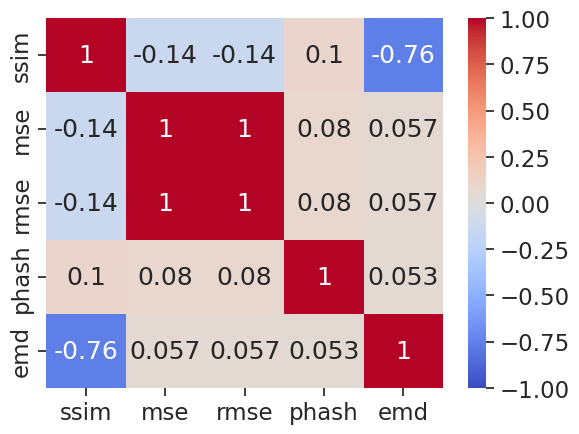

In [464]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = ds_src_overall_dict_v0[['ssim', 'mse', 'rmse', 'phash', 'emd']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()


#### Inference about ...

Merge all ... datasets ... of scenarios ...

In [434]:
ds_src_agg_v0 = pd.concat([
    ds_src_overall_dict_v0,
    ds_src_intra_animal_dict_v0,
    ds_src_intra_farm_dict_v0,
    ds_src_between_farm_dict_v0,    
])

ds_src_agg_v0.shape

(28162, 10)

Add os valores de QI referentes às duas imagens usadas na comparação ...

In [411]:
ds_src_agg_v1 = ds_src_agg_v0.merge(
    ds_lo_vy_img_v0, 
    left_on='img1_name',
    right_on='depth',
    how='left',
).drop(columns='depth').rename(columns={'lo':'img1_lo'})

ds_src_agg_v2 = ds_src_agg_v1.merge(
    ds_lo_vy_img_v0, 
    left_on='img2_name',
    right_on='depth',
    how='left',
).drop(columns='depth').rename(columns={'lo':'img2_lo'})

ds_src_agg_v2.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd,ssim_phash,ssim_phash_d,img1_lo,img2_lo
0,intra-farm,egbveuFX7hSAg8Cgwuya,Divino - Curral 1,0062_5176_2025_01_25_11_08_03_541779_DEPTH_320_240_1.png,0071vd_6989_2025_01_25_16_52_25_160971_DEPTH_320_240_1.png,0.219920,0.066773,0.207580,32,0.067469,0.006664,0.226940,195.126207,97.470573
1,intra-farm,NAmvD9ytvupDGxiV3C4a,Divino - Curral 1,0128_2742_2025_01_25_10_50_03_868761_DEPTH_320_240_1.png,0024vd_8771_2025_01_25_16_58_17_816181_DEPTH_320_240_1.png,0.227025,0.032428,0.155172,0,0.057417,0.227025,0.006579,170.023285,98.635294
2,intra-farm,ji3O1Lv5gg38uStwh8eI,Jarbson,5mf_14451_2025_01_25_17_45_44_743864_DEPTH_320_240_1.png,0024br_12371_2025_01_25_17_18_53_438547_DEPTH_320_240_1.png,0.666195,0.004773,0.044140,32,0.008690,0.020188,0.213417,95.642908,102.808270
3,intra-farm,IKcaWgp5Sjx6h5JeMPM4,Jarbson,0127vd_12316_2025_01_25_17_18_35_557354_DEPTH_320_240_1.png,0131az_12258_2025_01_25_17_18_15_735187_DEPTH_320_240_1.png,0.615528,0.003691,0.040602,32,0.004138,0.018652,0.214952,100.819501,99.832883
4,intra-farm,SfCAdVVBlzveBsOAmKtf,Divino - Curral 1,975_2053_2025_01_25_10_46_32_720234_DEPTH_320_240_1.png,4mf_14390_2025_01_25_17_45_05_204438_DEPTH_320_240_1.png,0.252205,0.036635,0.165978,32,0.047076,0.007643,0.225962,180.112093,96.528115


Measure the distance ratio between ....

- **ssim_phash**: represents ...
- **ssim_phash_d**: is ....

In [439]:
ds_src_agg_v0['ssim_phash'] = ds_src_agg_v0['ssim'] / (ds_src_agg_v0['phash'] + 1)
ds_src_agg_v0.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd,ssim_phash
0,intra-farm,egbveuFX7hSAg8Cgwuya,Divino - Curral 1,0062_5176_2025_01_25_11_08_03_541779_DEPTH_320_240_1.png,0071vd_6989_2025_01_25_16_52_25_160971_DEPTH_320_240_1.png,0.219920,0.066773,0.207580,32,0.067469,0.006664
1,intra-farm,NAmvD9ytvupDGxiV3C4a,Divino - Curral 1,0128_2742_2025_01_25_10_50_03_868761_DEPTH_320_240_1.png,0024vd_8771_2025_01_25_16_58_17_816181_DEPTH_320_240_1.png,0.227025,0.032428,0.155172,0,0.057417,0.227025
2,intra-farm,ji3O1Lv5gg38uStwh8eI,Jarbson,5mf_14451_2025_01_25_17_45_44_743864_DEPTH_320_240_1.png,0024br_12371_2025_01_25_17_18_53_438547_DEPTH_320_240_1.png,0.666195,0.004773,0.044140,32,0.008690,0.020188
3,intra-farm,IKcaWgp5Sjx6h5JeMPM4,Jarbson,0127vd_12316_2025_01_25_17_18_35_557354_DEPTH_320_240_1.png,0131az_12258_2025_01_25_17_18_15_735187_DEPTH_320_240_1.png,0.615528,0.003691,0.040602,32,0.004138,0.018652
4,intra-farm,SfCAdVVBlzveBsOAmKtf,Divino - Curral 1,975_2053_2025_01_25_10_46_32_720234_DEPTH_320_240_1.png,4mf_14390_2025_01_25_17_45_05_204438_DEPTH_320_240_1.png,0.252205,0.036635,0.165978,32,0.047076,0.007643


In [373]:
ds_src_agg_v0.describe()

,ssim,mse,rmse,phash,emd,ssim_phash,ssim_phash_d
count,2.816200e+04,2.816200e+04,28162.000000,28162.000000,28162.000000,2.816200e+04,28162.000000
mean,3.930235e-01,7.485157e+03,5.354611,12.245437,0.032309,2.353159e-01,0.177196
std,1.834237e-01,1.222923e+05,85.134705,15.601335,0.024031,2.235234e-01,0.136258
min,8.983901e-09,2.039234e-03,0.030407,0.000000,0.001078,2.722394e-10,0.000002
25%,2.460010e-01,6.879231e-03,0.051429,0.000000,0.008410,1.852334e-02,0.036713
50%,2.896563e-01,2.954587e-02,0.138197,0.000000,0.023112,2.336046e-01,0.213920
75%,6.235333e-01,4.053365e-02,0.168471,32.000000,0.055640,3.203760e-01,0.226317
max,7.207777e-01,2.027753e+06,1404.125122,48.000000,0.088755,7.207777e-01,0.487173


Evalute ... the graph demonstrate that ...

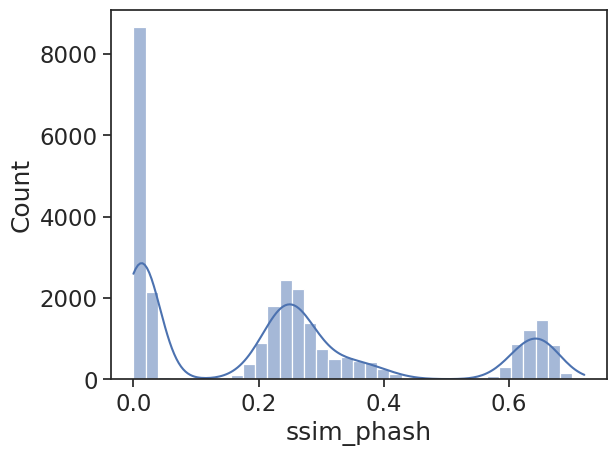

In [386]:
# Create the histogram
sns.histplot(x=ds_src_agg_v0['ssim_phash'], kde=True)
plt.show()

Considering the patthers ....

In [440]:
ssim_phash_m = np.median(ds_src_agg_v0['ssim_phash'])
ds_src_agg_v0['ssim_phash_d'] = np.abs(ds_src_agg_v0['ssim_phash'] - ssim_phash_m)

ds_src_agg_v0.head()

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd,ssim_phash,ssim_phash_d
0,intra-farm,egbveuFX7hSAg8Cgwuya,Divino - Curral 1,0062_5176_2025_01_25_11_08_03_541779_DEPTH_320_240_1.png,0071vd_6989_2025_01_25_16_52_25_160971_DEPTH_320_240_1.png,0.219920,0.066773,0.207580,32,0.067469,0.006664,0.226558
1,intra-farm,NAmvD9ytvupDGxiV3C4a,Divino - Curral 1,0128_2742_2025_01_25_10_50_03_868761_DEPTH_320_240_1.png,0024vd_8771_2025_01_25_16_58_17_816181_DEPTH_320_240_1.png,0.227025,0.032428,0.155172,0,0.057417,0.227025,0.006196
2,intra-farm,ji3O1Lv5gg38uStwh8eI,Jarbson,5mf_14451_2025_01_25_17_45_44_743864_DEPTH_320_240_1.png,0024br_12371_2025_01_25_17_18_53_438547_DEPTH_320_240_1.png,0.666195,0.004773,0.044140,32,0.008690,0.020188,0.213034
3,intra-farm,IKcaWgp5Sjx6h5JeMPM4,Jarbson,0127vd_12316_2025_01_25_17_18_35_557354_DEPTH_320_240_1.png,0131az_12258_2025_01_25_17_18_15_735187_DEPTH_320_240_1.png,0.615528,0.003691,0.040602,32,0.004138,0.018652,0.214569
4,intra-farm,SfCAdVVBlzveBsOAmKtf,Divino - Curral 1,975_2053_2025_01_25_10_46_32_720234_DEPTH_320_240_1.png,4mf_14390_2025_01_25_17_45_05_204438_DEPTH_320_240_1.png,0.252205,0.036635,0.165978,32,0.047076,0.007643,0.225579


##### Top-10 disco...

In [412]:
# as 10 maiores discordãncias
ds_src_agg_v2.sort_values(by='ssim_phash_d').head(10)

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd,ssim_phash,ssim_phash_d,img1_lo,img2_lo
6736,intra-farm,lfDcgA4V3DZ7c7ickaZZ,Divino - Curral 1,0126_1262_2025_01_25_10_42_32_088279_DEPTH_320_240_1.png,7mf_14619_2025_01_25_17_47_00_814692_DEPTH_320_240_1.png,0.233607,0.038242,0.168853,0,0.057117,0.233607,0.000002,176.563058,96.900862
26658,intra-farm,HRFbgX0KqvJH6IauCK13,Divino - Curral 1,985_819_2025_01_25_10_40_13_798216_DEPTH_320_240_1.png,0131az_12243_2025_01_25_17_18_14_262463_DEPTH_320_240_1.png,0.233603,0.036216,0.161485,0,0.055633,0.233603,0.000002,181.833249,101.750057
26661,intra-farm,3QhziFI8oXXGiVzmqQWR,Divino - Curral 1,0074_2305_2025_01_25_10_47_51_788343_DEPTH_320_240_1.png,66vdf_13640_2025_01_25_17_33_59_527884_DEPTH_320_240_1.png,0.233597,0.037912,0.165898,0,0.050060,0.233597,0.000008,180.129000,97.818997
20030,intra-farm,O5wPj3DHXhXi48GuPfD6,Divino - Curral 1,0014_547_2025_01_25_10_31_32_803637_DEPTH_320_240_1.png,0140qz_11067_2025_01_25_17_12_17_254593_DEPTH_320_240_1.png,0.233615,0.039017,0.168105,0,0.059417,0.233615,0.000011,183.557153,100.315038
3411,intra-farm,uwxxjlhEAUNb6O1E2Df5,Divino - Curral 1,996_1772_2025_01_25_10_45_14_245520_DEPTH_320_240_1.png,0134az_8119_2025_01_25_16_56_11_891118_DEPTH_320_240_1.png,0.233589,0.034657,0.158675,0,0.055456,0.233589,0.000015,176.390936,101.268696
22509,intra-farm,DfDcxhzb813jbkSKTgpv,Divino - Curral 1,509_3889_2025_01_25_11_00_09_625696_DEPTH_320_240_1.png,0028vm_12706_2025_01_25_17_20_24_438516_DEPTH_320_240_1.png,0.233630,0.038985,0.166538,0,0.063703,0.233630,0.000025,199.821714,100.900008
23546,intra-farm,DfDcxhzb813jbkSKTgpv,Divino - Curral 1,509_3889_2025_01_25_11_00_09_625696_DEPTH_320_240_1.png,0031az_10026_2025_01_25_17_05_00_219535_DEPTH_320_240_1.png,0.233577,0.037425,0.161828,0,0.055789,0.233577,0.000027,199.821714,98.831128
23515,intra-farm,DfDcxhzb813jbkSKTgpv,Divino - Curral 1,509_3889_2025_01_25_11_00_09_625696_DEPTH_320_240_1.png,0031az_10026_2025_01_25_17_05_00_219535_DEPTH_320_240_1.png,0.233577,0.037425,0.161828,0,0.055789,0.233577,0.000027,199.821714,98.831128
21648,intra-farm,021IK4BJ2GltxzphIRtY,Divino - Curral 1,0200_15570_2025_01_26_09_07_58_448220_DEPTH_320_240_1.png,0013ro_10148_2025_01_25_17_06_06_343680_DEPTH_320_240_1.png,0.233633,0.054166,0.192076,0,0.051870,0.233633,0.000028,180.230350,96.232029
5854,intra-farm,oPpZinsihcLhefcHafvt,Jarbson,0507vd_11296_2025_01_25_17_13_14_039302_DEPTH_320_240_1.png,0438_3299_2025_01_25_10_53_52_386855_DEPTH_320_240_1.png,0.233562,0.042418,0.172675,0,0.040219,0.233562,0.000043,96.597299,211.779446


##### Top-congr1

In [413]:
# as 10 maiores congruências positivas
ds_src_agg_v2.sort_values(by='ssim_phash', ascending=False).head(10)

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd,ssim_phash,ssim_phash_d,img1_lo,img2_lo
9833,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7748_2025_01_25_16_54_17_639806_DEPTH_320_240_1.png,0068vd_7749_2025_01_25_16_54_17_751722_DEPTH_320_240_1.png,0.720778,0.002287,0.031630,0,0.005086,0.720778,0.487173,101.139788,103.090257
9815,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7730_2025_01_25_16_54_15_763414_DEPTH_320_240_1.png,0068vd_7731_2025_01_25_16_54_15_857768_DEPTH_320_240_1.png,0.718447,0.002130,0.030875,0,0.003930,0.718447,0.484843,101.162005,102.150423
2265,intra-farm,MFLbC4IjyPVKmai3Wfdl,Jarbson,0606az_7269_2025_01_25_16_53_09_168600_DEPTH_320_240_1.png,0041vd_6613_2025_01_25_16_50_18_574617_DEPTH_320_240_1.png,0.714811,0.002637,0.033910,0,0.008310,0.714811,0.481207,100.653971,93.898955
9813,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7728_2025_01_25_16_54_15_559853_DEPTH_320_240_1.png,0068vd_7729_2025_01_25_16_54_15_669681_DEPTH_320_240_1.png,0.713944,0.002287,0.031180,0,0.005102,0.713944,0.480339,103.852445,101.768185
9827,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7742_2025_01_25_16_54_17_001304_DEPTH_320_240_1.png,0068vd_7743_2025_01_25_16_54_17_097078_DEPTH_320_240_1.png,0.713886,0.002321,0.031570,0,0.004091,0.713886,0.480282,101.750240,101.591028
9798,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7713_2025_01_25_16_54_13_945405_DEPTH_320_240_1.png,0068vd_7714_2025_01_25_16_54_14_040613_DEPTH_320_240_1.png,0.713302,0.002432,0.032132,0,0.002760,0.713302,0.479697,100.076204,101.878843
9799,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7714_2025_01_25_16_54_14_040613_DEPTH_320_240_1.png,0068vd_7715_2025_01_25_16_54_14_139624_DEPTH_320_240_1.png,0.713184,0.002182,0.030902,0,0.006310,0.713184,0.479579,101.878843,102.591623
15157,intra-farm,bfEJhCOdSfS4FDuILRKk,Jarbson,0124vd_12808_2025_01_25_17_20_50_629955_DEPTH_320_240_1.png,0028vm_12703_2025_01_25_17_20_24_132975_DEPTH_320_240_1.png,0.712697,0.002434,0.031873,0,0.003870,0.712697,0.479093,103.856840,100.192691
9819,intra-animal,XPRFfkS1Fx8U4BB7TBRH,Jarbson,0068vd_7734_2025_01_25_16_54_16_139191_DEPTH_320_240_1.png,0068vd_7735_2025_01_25_16_54_16_264191_DEPTH_320_240_1.png,0.712061,0.003944,0.034841,0,0.006677,0.712061,0.478457,102.158785,98.692882
9226,intra-animal,2cxH3edqfiAyRCiS12jq,Jarbson,0134az_8138_2025_01_25_16_56_13_749112_DEPTH_320_240_1.png,0134az_8139_2025_01_25_16_56_13_851299_DEPTH_320_240_1.png,0.712016,0.002041,0.030595,0,0.003932,0.712016,0.478411,103.284108,103.218402


##### Top-10 congr2

In [414]:
# as 10 maiores congruências pra baixo
ds_src_agg_v2.sort_values(by='ssim_phash', ascending=True).head(10)

,src_type,thing_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd,ssim_phash,ssim_phash_d,img1_lo,img2_lo
23001,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3673_2025_01_25_10_58_57_110697_DEPTH_320_240_1.png,0138az_12918_2025_01_25_17_21_59_823777_DEPTH_320_240_1.png,8.983901e-09,2004970.875,1393.299683,32,0.073185,2.722394e-10,0.233605,183.941741,96.162203
22043,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3675_2025_01_25_10_58_57_324810_DEPTH_320_240_1.png,0034az_9332_2025_01_25_17_01_34_699796_DEPTH_320_240_1.png,1.403087e-08,2010860.375,1399.108765,34,0.080122,4.008819e-10,0.233605,187.907195,101.973785
19812,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3677_2025_01_25_10_58_57_534332_DEPTH_320_240_1.png,1mf_14191_2025_01_25_17_42_40_653398_DEPTH_320_240_1.png,1.518998e-08,2015921.875,1400.938110,32,0.082036,4.603025e-10,0.233605,183.812894,95.987274
22464,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3670_2025_01_25_10_58_56_798206_DEPTH_320_240_1.png,0133az_12962_2025_01_25_17_22_24_960883_DEPTH_320_240_1.png,2.401658e-08,1998544.625,1395.902832,32,0.081018,7.277750e-10,0.233605,182.699779,95.081010
23902,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3669_2025_01_25_10_58_56_692475_DEPTH_320_240_1.png,0123vd_12762_2025_01_25_17_20_35_347433_DEPTH_320_240_1.png,2.811338e-08,2008824.750,1398.882935,32,0.076924,8.519205e-10,0.233605,184.884627,102.112062
20684,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3675_2025_01_25_10_58_57_324810_DEPTH_320_240_1.png,0506vd_8873_2025_01_25_16_59_03_285818_DEPTH_320_240_1.png,2.839993e-08,2010871.250,1399.112305,32,0.080060,8.606039e-10,0.233605,187.907195,99.734829
4583,intra-farm,52XNHvcgyKJnGL68GFkB,Jarbson,0120vd_10683_2025_01_25_17_10_33_025875_DEPTH_320_240_1.png,1001_3675_2025_01_25_10_58_57_324810_DEPTH_320_240_1.png,2.074340e-08,2010822.625,1399.095093,22,0.085727,9.018870e-10,0.233605,97.528679,187.907195
23249,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3672_2025_01_25_10_58_57_012022_DEPTH_320_240_1.png,0116vd_13014_2025_01_25_17_22_37_064579_DEPTH_320_240_1.png,3.077806e-08,1998206.125,1390.757568,32,0.078021,9.326686e-10,0.233605,183.155962,98.463111
19414,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3675_2025_01_25_10_58_57_324810_DEPTH_320_240_1.png,0610az_10451_2025_01_25_17_09_06_121387_DEPTH_320_240_1.png,3.955647e-08,2010884.250,1399.115723,32,0.077685,1.198681e-09,0.233605,187.907195,99.954681
27067,intra-farm,0H0P02DmDniAyI9krMhA,Divino - Curral 1,1001_3671_2025_01_25_10_58_56_901236_DEPTH_320_240_1.png,0041vd_6654_2025_01_25_16_50_28_123575_DEPTH_320_240_1.png,4.151140e-08,1991257.375,1391.612305,32,0.078878,1.257921e-09,0.233605,183.260060,97.278614


### 3.5 Qualitative Analysis

Compare ...

In [479]:
import matplotlib as mpl

mpl.rc('xtick', labelsize=12) 
mpl.rc('ytick', labelsize=12) 

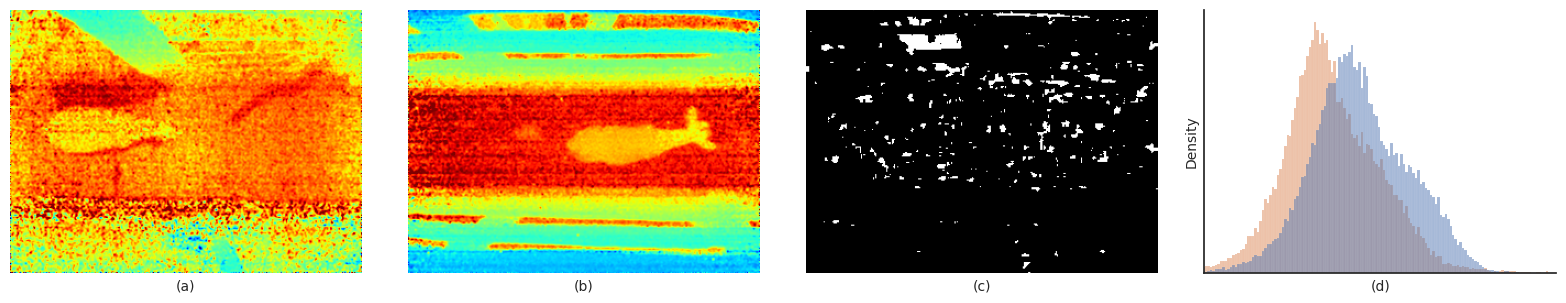

In [578]:
img1 = images_by_depth['985_819_2025_01_25_10_40_13_798216_DEPTH_320_240_1.png']
img2 = images_by_depth['0131az_12243_2025_01_25_17_18_14_262463_DEPTH_320_240_1.png']

from skimage.metrics import structural_similarity as ssim
_, mask = ssim(img1, img2, full=True, data_range=1)

# ????
mask = mask > 0.6

# Perform the 2D Fast Fourier Transform (FFT)
f_transform1 = np.fft.fft2(img1)
f_transform2 = np.fft.fft2(img2)

arr1 = np.log(np.abs(f_transform1.flatten()))
arr2 = np.log(np.abs(f_transform2.flatten()))

hist_df = pd.DataFrame({
    'value': np.concatenate([arr1, arr2]), 
    'img': ['img1']*len(arr1) + ['img2']*len(arr2)
})

# Visualization
_cmap = 'jet'

fig, ax = plt.subplots(1, 4, figsize=(16, 12))

ax[0].imshow(img1, cmap=_cmap); 
ax[0].set_xlabel('(a)')

ax[1].imshow(img2, cmap=_cmap); 
ax[1].set_xlabel('(b)')

ax[2].imshow(mask2, cmap='grey'); 
ax[2].set_xlabel('(c)')

sns.histplot(hist_df, x='value', hue='img', stat="density", ax=ax[3], legend=True);
sns.despine()

ax[3].set_box_aspect(0.75)
ax[3].set_xlabel('(d)')
ax[3].set_xlim(-1, 6)
ax[3].get_legend().remove()
ax[3].set_xticks([])
ax[3].set_yticks([])

for x in ax[:3]:
    x.set_xticks([])
    x.set_yticks([])
    for spine in x.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("output/fig_07b_ssim_x_pHash_samples.png", dpi=300, bbox_inches="tight")

plt.show()